In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

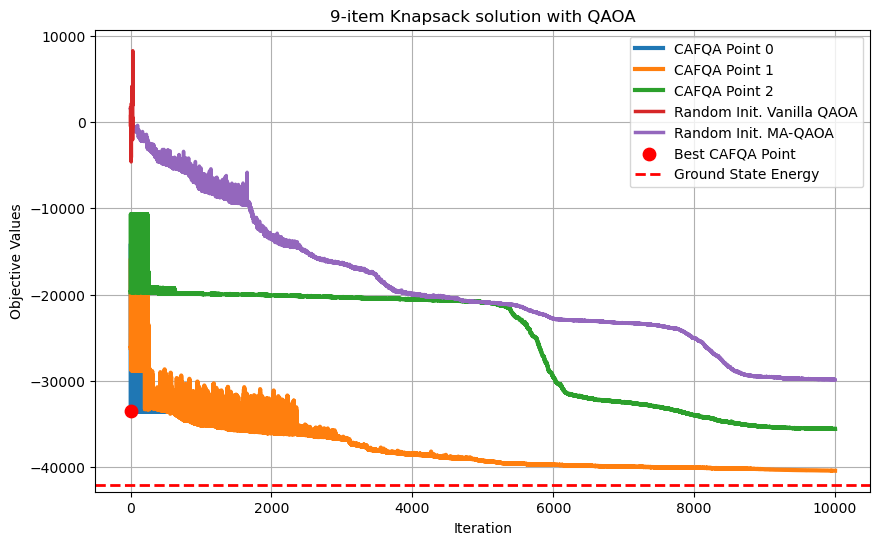

In [29]:
#Approx Ratio

cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Knapsack/9_items/result_5.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'task_{i}' for i in range(3)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}
exact_energy = cafqa_diff_points_data['Exact_Ground_State_Energy']
# Plot all obj_values on the same plot
plt.figure(figsize=(10, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA Point {i}', linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', linewidth=2.5,zorder=10)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA', linewidth=2.5)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.scatter(0, obj_values['task_0'][0], color='red', s=80, zorder=5, label='Best CAFQA Point')
plt.axhline(y=exact_energy, color='red', linestyle='--', linewidth=2, label='Ground State Energy')
plt.legend()
plt.grid()
plt.title('9-item Knapsack solution with QAOA')
plt.savefig('../plots/knapsack_qaoa_9_item.png', dpi=500, bbox_inches='tight')
plt.show()


In [3]:
# cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['approx_ratio'],cafqa_diff_points_data['Task_results']['task_2']['approx_ratio']

In [5]:
def compute_cafqa_vs_random_stats(num_qubits):
    random_total = 0 
    cafqa_total = 0
    random_relative_error = 0 
    cafqa_relative_error = 0

    random_approx_ratios = []
    cafqa_approx_ratios = []
    cafqa_accuracies = []
    random_relative_errors = []
    cafqa_relative_errors = []

    for i in range(1, 11):
        data = np.load(f'../np_data/Final_Data_Collection/Maxcut/K_Reg_Graphs/{num_qubits}_qbs/result_{i}.npy', allow_pickle=True).item()
        random_ratio = data['Task_results']['Random_MA-QAOA']['approx_ratio']
        random_fin_energy = data['Task_results']['Random_MA-QAOA']['final_energy']
        random_total += random_ratio
        random_approx_ratios.append(random_ratio)
        exact_energy = data['Exact_Ground_State_Energy']
        max_approx_ratio = max(
            data['Task_results'][task]['approx_ratio']
            for task in data['Task_results'] if task.startswith('task_')
        )

        min_cafqa_fin_energy = min(
            data['Task_results'][task]['final_energy']
            for task in data['Task_results'] if task.startswith('task_')
        )

        random_err = abs((exact_energy - random_fin_energy) / exact_energy)
        cafqa_err = abs((exact_energy - min_cafqa_fin_energy) / exact_energy)
        random_relative_error += random_err
        cafqa_relative_error += cafqa_err
        random_relative_errors.append(random_err)
        cafqa_relative_errors.append(cafqa_err)

        cafqa_total += max_approx_ratio
        cafqa_approx_ratios.append(max_approx_ratio)

        cafqa_accuracy = data['CAFQA_initialization_energy'] / exact_energy
        cafqa_accuracies.append(cafqa_accuracy)

    random_std = np.std(random_approx_ratios)
    cafqa_std = np.std(cafqa_approx_ratios)
    random_relerr_std = np.std(random_relative_errors)
    cafqa_relerr_std = np.std(cafqa_relative_errors)

    avg_random_approx_ratio = random_total / 10
    avg_cafqa_approx_ratio = cafqa_total / 10

    avg_random_relative_error = random_relative_error / 10
    avg_cafqa_relative_error = cafqa_relative_error / 10
    
    mean_cafqa_accuracy = np.mean(cafqa_accuracies)

    print(f"Mean CAFQA accuracy: {mean_cafqa_accuracy:.4f}")
    print(f"Random MA-QAOA: {avg_random_approx_ratio:.4f} ± {random_std:.4f}")
    print(f"CAFQA (best of 4): {avg_cafqa_approx_ratio:.4f} ± {cafqa_std:.4f}")
    print(f"Mean relative error (Random MA-QAOA vs exact): {avg_random_relative_error:.4f} ± {random_relerr_std:.4f}")
    print(f"Mean relative error (CAFQA best vs exact): {avg_cafqa_relative_error:.4f} ± {cafqa_relerr_std:.4f}")
    return {
        'mean_cafqa_accuracy': mean_cafqa_accuracy,
        'avg_random_approx_ratio': avg_random_approx_ratio,
        'random_std': random_std,
        'avg_cafqa_approx_ratio': avg_cafqa_approx_ratio,
        'cafqa_std': cafqa_std,
        'avg_random_relative_error': avg_random_relative_error,
        'random_relerr_std': random_relerr_std,
        'avg_cafqa_relative_error': avg_cafqa_relative_error,
        'cafqa_relerr_std': cafqa_relerr_std,
    }

compute_cafqa_vs_random_stats(16)

Mean CAFQA accuracy: 0.7246
Random MA-QAOA: 0.9237 ± 0.0300
CAFQA (best of 4): 0.9288 ± 0.0360
Mean relative error (Random MA-QAOA vs exact): 0.1651 ± 0.0607
Mean relative error (CAFQA best vs exact): 0.1533 ± 0.0736


{'mean_cafqa_accuracy': np.float64(0.7246196087673022),
 'avg_random_approx_ratio': 0.9237141535542527,
 'random_std': np.float64(0.02999131821305657),
 'avg_cafqa_approx_ratio': 0.9287518295094136,
 'cafqa_std': np.float64(0.03600918686782783),
 'avg_random_relative_error': np.float64(0.1650520023742797),
 'random_relerr_std': np.float64(0.06073613880134271),
 'avg_cafqa_relative_error': np.float64(0.15331585496471162),
 'cafqa_relerr_std': np.float64(0.07362641064761291)}

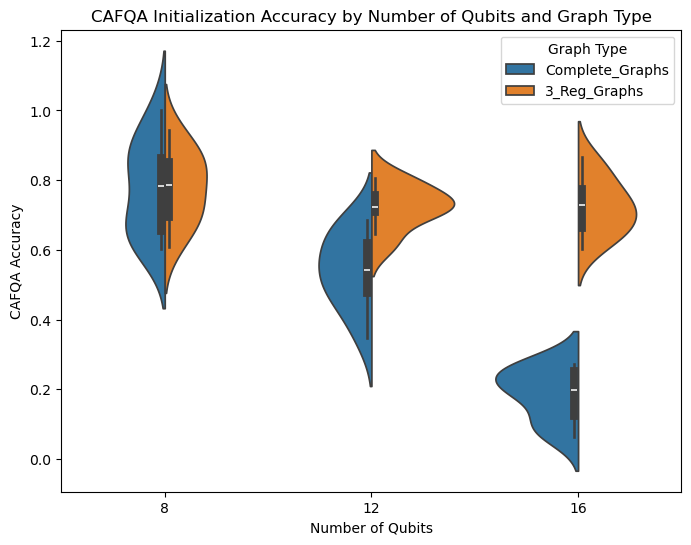

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# Collect CAFQA accuracy data for both Maxcut and K_Reg_Graphs
cafqa_accuracies = []
graph_types = []
num_qubits_col = []

num_qubits_list = [8, 12, 16]
graph_categories = ['Complete_Graphs', '3_Reg_Graphs']

for graph_type in graph_categories:
    for num_qubits in num_qubits_list:
        for idx in range(1, 11):
            if graph_type == 'Complete_Graphs':
                data_path = f'../np_data/Final_Data_Collection/Maxcut/Complete_Graphs/{num_qubits}_qbs/result_{idx}.npy'
            else:
                data_path = f'../np_data/Final_Data_Collection/Maxcut/K_Reg_Graphs/{num_qubits}_qbs/result_{idx}.npy'
            if not os.path.exists(data_path):
                continue
            data = np.load(data_path, allow_pickle=True).item()
            accuracy = data['CAFQA_initialization_energy'] / data['Exact_Ground_State_Energy']
            cafqa_accuracies.append(accuracy)
            graph_types.append(graph_type)
            num_qubits_col.append(num_qubits)

# Create DataFrame for plotting
df = pd.DataFrame({
    'CAFQA Accuracy': cafqa_accuracies,
    'Number of Qubits': num_qubits_col,
    'Graph Type': graph_types
})

plt.figure(figsize=(8, 6))
sns.violinplot(
    data=df,
    x='Number of Qubits',
    y='CAFQA Accuracy',
    hue='Graph Type',
    split=True
)
plt.xlabel('Number of Qubits')
plt.ylabel('CAFQA Accuracy')
plt.title('CAFQA Initialization Accuracy by Number of Qubits and Graph Type')
plt.legend(title='Graph Type')
# plt.savefig('../plots/maxcut_cafqa_accuracy_violinplot.png', dpi=500, bbox_inches='tight')
plt.show()

In [7]:
teague_10qb_data = np.load('../np_data/CAFQA_Analysis/Teague_data/14_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy', allow_pickle=True).item()
exact_energy = teague_10qb_data['Exact_Ground_State_Energy'] if 'Exact_Ground_State_Energy' in teague_10qb_data else None

if exact_energy is None:
    # Try to infer from best of all tasks
    exact_energy = min(
        teague_10qb_data['Task_results'][task]['final_energy']
        for task in teague_10qb_data['Task_results']
        if 'final_energy' in teague_10qb_data['Task_results'][task]
    )

random_final_energy = teague_10qb_data['Task_results']['Random_MA-QAOA']['final_energy']
cafqa_final_energy = min(
    teague_10qb_data['Task_results'][task]['final_energy']
    for task in teague_10qb_data['Task_results']
    if task.startswith('task_')
)

random_rel_error = abs((exact_energy - random_final_energy) / exact_energy)
cafqa_rel_error = abs((exact_energy - cafqa_final_energy) / exact_energy)

print(f"Random MA-QAOA relative error: {random_rel_error:.4f}")
print(f"CAFQA (best of 5) relative error: {cafqa_rel_error:.4f}")



Random MA-QAOA relative error: 0.6014
CAFQA (best of 5) relative error: 0.0000


# Knapsack 

In [8]:
def compute_cafqa_vs_random_stats_no_approx(num_items):
    random_relative_error = 0 
    cafqa_relative_error = 0

    cafqa_accuracies = []
    random_relative_errors = []
    cafqa_relative_errors = []

    for i in range(1, 11):
        data = np.load(f'../np_data/Final_Data_Collection/Knapsack/{num_items}_items/result_{i}.npy', allow_pickle=True).item()
        random_fin_energy = data['Task_results']['Random_MA-QAOA']['final_energy']
        exact_energy = data['Exact_Ground_State_Energy']

        min_cafqa_fin_energy = min(
            data['Task_results'][task]['final_energy']
            for task in data['Task_results'] if task.startswith('task_')
        )

        random_err = abs((exact_energy - random_fin_energy) / exact_energy)
        cafqa_err = abs((exact_energy - min_cafqa_fin_energy) / exact_energy)
        random_relative_error += random_err
        cafqa_relative_error += cafqa_err
        random_relative_errors.append(random_err)
        cafqa_relative_errors.append(cafqa_err)

        cafqa_accuracy = data['CAFQA_initialization_energy'] / exact_energy
        cafqa_accuracies.append(cafqa_accuracy)

    random_relerr_std = np.std(random_relative_errors)
    cafqa_relerr_std = np.std(cafqa_relative_errors)

    avg_random_relative_error = random_relative_error / 10
    avg_cafqa_relative_error = cafqa_relative_error / 10
    
    mean_cafqa_accuracy = np.mean(cafqa_accuracies)

    print(f"Mean CAFQA accuracy: {mean_cafqa_accuracy:.4f}")
    print(f"Mean relative error (Random MA-QAOA vs exact): {avg_random_relative_error:.4f} ± {random_relerr_std:.4f}")
    print(f"Mean relative error (CAFQA best vs exact): {avg_cafqa_relative_error:.4f} ± {cafqa_relerr_std:.4f}")
    return {
        'mean_cafqa_accuracy': mean_cafqa_accuracy,
        'avg_random_relative_error': avg_random_relative_error,
        'random_relerr_std': random_relerr_std,
        'avg_cafqa_relative_error': avg_cafqa_relative_error,
        'cafqa_relerr_std': cafqa_relerr_std,
    }

compute_cafqa_vs_random_stats_no_approx(12)

Mean CAFQA accuracy: 0.2068
Mean relative error (Random MA-QAOA vs exact): 0.4652 ± 0.1295
Mean relative error (CAFQA best vs exact): 0.3541 ± 0.0904


{'mean_cafqa_accuracy': np.float64(0.20675407362967385),
 'avg_random_relative_error': np.float64(0.4651799829655648),
 'random_relerr_std': np.float64(0.1295249717139555),
 'avg_cafqa_relative_error': np.float64(0.3541041589057981),
 'cafqa_relerr_std': np.float64(0.09036136333119064)}

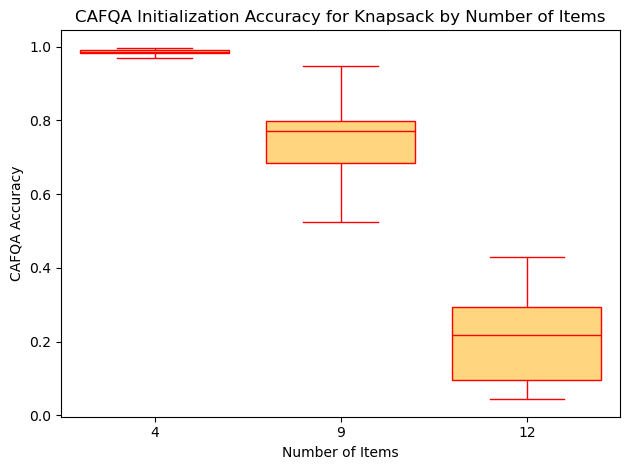

In [14]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Collect CAFQA accuracy data for Knapsack with different item sizes
cafqa_accuracies = []
item_sizes = []

item_sizes_list = [4, 9, 12]

for num_items in item_sizes_list:
    for idx in range(1, 11):
        data_path = f'../np_data/Final_Data_Collection/Knapsack/{num_items}_items/result_{idx}.npy'
        if not os.path.exists(data_path):
            continue
        data = np.load(data_path, allow_pickle=True).item()
        accuracy = data['CAFQA_initialization_energy'] / data['Exact_Ground_State_Energy']
        cafqa_accuracies.append(accuracy)
        item_sizes.append(num_items)

# Create DataFrame for plotting
df_knapsack = pd.DataFrame({
    'CAFQA Accuracy': cafqa_accuracies,
    'Number of Items': item_sizes
})

# Custom boxplot with light orange color
sns.boxplot(
    data=df_knapsack,
    x='Number of Items',
    y='CAFQA Accuracy',
    boxprops=dict(facecolor='#FFD580', edgecolor='red'),  # light orange hex
    medianprops=dict(color='red'),
    whiskerprops=dict(color='red'),
    capprops=dict(color='red'),
    flierprops=dict(marker='o', color='red', markeredgecolor='red')
)

plt.xlabel('Number of Items')
plt.ylabel('CAFQA Accuracy')
plt.title('CAFQA Initialization Accuracy for Knapsack by Number of Items')
plt.savefig('../plots/knapsack_cafqa_accuracy_boxplot.png', dpi=500, bbox_inches='tight')
plt.tight_layout()
plt.show()
